<a href="https://colab.research.google.com/github/christiangarza1505813/Tesina/blob/main/Model/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip -q install pandas pyarrow scikit-learn joblib
!pip install pydeck
!pip install xgboost

In [42]:


import matplotlib.pyplot as plt
import seaborn as sns
import io, os, textwrap, joblib, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error,average_precision_score, brier_score_loss,classification_report,confusion_matrix
pd.set_option('future.no_silent_downcasting', True)



from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


In [3]:
CSV_URL = "https://raw.githubusercontent.com/christiangarza1505813/Tesina/main/Datos/user_clasification.csv"  # <-- reemplaza

df = pd.read_csv(
    CSV_URL,
)

In [4]:
CSV_Demo = "https://raw.githubusercontent.com/christiangarza1505813/Tesina/main/Datos/Demo.csv"  # <-- reemplaza

df_demo = pd.read_csv(
    CSV_Demo,
)

In [5]:
df_demo.columns

Index(['demo[ZCTA5]', '[% Mexicanos]', '[% Negros]', '[% Blancos]',
       '[% Latinos]', '[% Asiaticos]', '[% Otros - no hispanos]'],
      dtype='object')

In [6]:

df = df.merge(
    df_demo[['demo[ZCTA5]', '[% Mexicanos]', '[% Negros]', '[% Blancos]',
       '[% Latinos]', '[% Asiaticos]', '[% Otros - no hispanos]']]  # solo las columnas necesarias
        .rename(columns={'Hispanic Percent Population': 'Hispanic_percent'}),  # renombrar
    how='left',               # left join para no perder registros de df
    left_on='postal_code',    # columna en df
    right_on='demo[ZCTA5]'    # columna en df_demo
)

df = df.drop(columns=['demo[ZCTA5]'])


In [7]:
df['YMD'] = pd.to_datetime(df['YMD'])
df['YearOfBirth'] = df['YearOfBirth'].astype(int)
df['Creation_date'] = pd.to_datetime(df['Creation_date'])
df_sorted = df.sort_values(by=['AccountUuid', 'YMD'])
df = df_sorted.drop_duplicates(subset=['AccountUuid'], keep='first')
df.describe()

,YMD,Creation_date,Plaid,Issued_Card,Transacting,Pmt_method,YearOfBirth,postal_code,lat,lng,density,[% Mexicanos],[% Negros],[% Blancos],[% Latinos],[% Asiaticos],[% Otros - no hispanos]
count,67678,67678,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67582.000000,67582.000000,67582.000000,67582.000000,67582.000000,67582.000000
mean,2024-06-23 07:05:41.605839104,2024-06-17 02:28:14.305387264,0.042362,0.608839,0.313810,0.132672,1988.604968,64218.323680,35.987574,-98.183960,1668.881913,0.268162,0.138192,0.452421,0.065437,0.045963,0.029728
min,2022-08-08 00:00:00,2022-08-08 00:00:00,0.000000,0.000000,0.000000,0.000000,1900.000000,10002.000000,19.306120,-166.471250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-12-25 06:00:00,2023-12-16 00:00:00,0.000000,0.000000,0.000000,0.000000,1983.000000,37241.250000,32.934170,-115.123130,144.700000,0.044000,0.020000,0.199000,0.020000,0.007000,0.015000
50%,2024-05-09 00:00:00,2024-05-02 00:00:00,0.000000,1.000000,0.000000,0.000000,1990.000000,75141.000000,35.249220,-95.870100,821.300000,0.167000,0.070000,0.441000,0.039000,0.020000,0.024000
75%,2024-12-30 00:00:00,2024-12-23 00:00:00,0.000000,1.000000,1.000000,0.000000,1996.000000,89104.000000,39.723890,-84.549560,1931.500000,0.445000,0.184000,0.697000,0.071000,0.054000,0.037000
max,2025-09-13 00:00:00,2025-09-13 00:00:00,1.000000,1.000000,1.000000,1.000000,2007.000000,99901.000000,67.254350,-72.372230,58289.600000,1.000000,0.988000,1.000000,0.961000,0.736000,0.950000
std,NaN,NaN,0.201416,0.488014,0.464043,0.339223,10.402508,26328.559487,4.846153,15.499654,3232.997743,0.263344,0.175627,0.283249,0.090880,0.072288,0.030557


#Calidad de los datos


##% de nulos

In [8]:

obj_cols = df.select_dtypes(include=['object', 'string']).columns

# Máscaras de vacíos y nulos
mask_empty = pd.DataFrame(False, index=df.index, columns=df.columns)
if len(obj_cols):
    mask_empty[obj_cols] = df[obj_cols].astype('string').apply(lambda s: s.str.strip().eq(''))

mask_null = df.isna()

# Resumen en porcentaje
resumen = pd.DataFrame({
    'Tipo': df.dtypes.astype(str),
    '% nulos o vacíos': ((mask_null | mask_empty).mean()*100).round(2)
}).sort_values('% nulos o vacíos', ascending=False)

sty = (resumen.style
       .format({'% nulos':'{:.2f} %','% vacíos':'{:.2f} %','% nulos o vacíos':'{:.2f} %'})
       .set_table_styles([
           {'selector': 'table', 'props': 'border-collapse:collapse; border:1px solid black; background:white; color:black; font-family:"Times New Roman",serif; font-size:12px;'},
           {'selector': 'th',    'props': 'border:1px solid black; padding:4px; text-align:center; font-weight:bold;'},
           {'selector': 'td',    'props': 'border:1px solid black; padding:4px; text-align:right;'},
           {'selector': 'th.row_heading', 'props': 'text-align:left;'}  # nombres de columnas (índice) alineados a la izquierda
       ])
)
display(sty)

,Tipo,% nulos o vacíos
[% Mexicanos],float64,0.14 %
[% Asiaticos],float64,0.14 %
[% Otros - no hispanos],float64,0.14 %
[% Latinos],float64,0.14 %
[% Blancos],float64,0.14 %
[% Negros],float64,0.14 %
Issued_Card,float64,0.00 %
Creation_date,datetime64[ns],0.00 %
YMD,datetime64[ns],0.00 %
AccountUuid,object,0.00 %


##Datos únicos

In [9]:


n = len(df)
non_null = df.notna().sum()
uniq_no_na = df.nunique(dropna=True)   # distintos excluyendo NaN
uniq_with_na = df.nunique(dropna=False) # cuenta NaN como categoría

resumen = pd.DataFrame({
    'N': n,
    'Distintos': uniq_no_na,
    '% únicos / total': np.where(n>0, (uniq_no_na / n * 100).round(2), 0.0)
}).sort_values('% únicos / total', ascending=False)

# Estilo blanco y negro (tipo “IEEE”)
sty = (resumen.style
       .format({'% únicos / no nulos':'{:.2f} %', '% únicos / total':'{:.2f} %'})
       .set_table_styles([
           {'selector': 'table', 'props': 'border-collapse:collapse; border:1px solid black; background:white; color:black; font-family:"Times New Roman",serif; font-size:12px;'},
           {'selector': 'th',    'props': 'border:1px solid black; padding:4px; text-align:center; font-weight:bold;'},
           {'selector': 'td',    'props': 'border:1px solid black; padding:4px; text-align:right;'},
           {'selector': 'th.row_heading', 'props': 'text-align:left;'}
       ])
)
display(sty)


,N,Distintos,% únicos / total
AccountUuid,67678,67678,100.00 %
postal_code,67678,10474,15.48 %
lng,67678,10452,15.44 %
lat,67678,10446,15.43 %
density,67678,6212,9.18 %
city,67678,5252,7.76 %
[% Blancos],67678,998,1.47 %
Creation_date,67678,998,1.47 %
YMD,67678,992,1.47 %
[% Negros],67678,847,1.25 %


##Validacíón de rangos

In [10]:
# Mín y máx por columna (numéricas y datetimes)
rangos = (df.describe()
            .loc[['min','max']]
            .T)

# Estilo monocromo tipo “IEEE”
sty = (rangos.style
       .set_table_styles([
           {'selector':'table','props':'border-collapse:collapse;border:1px solid black;background:white;color:black;font-family:"Times New Roman",serif;font-size:12px;'},
           {'selector':'th','props':'border:1px solid black;padding:4px;text-align:center;font-weight:bold;'},
           {'selector':'td','props':'border:1px solid black;padding:4px;text-align:right;'},
           {'selector':'th.row_heading','props':'text-align:left;'}
       ])
       .format(na_rep='—')
)
display(sty)


,min,max
YMD,2022-08-08 00:00:00,2025-09-13 00:00:00
Creation_date,2022-08-08 00:00:00,2025-09-13 00:00:00
Plaid,0.000000,1.000000
Issued_Card,0.000000,1.000000
Transacting,0.000000,1.000000
Pmt_method,0.000000,1.000000
YearOfBirth,1900.000000,2007.000000
postal_code,10002.000000,99901.000000
lat,19.306120,67.254350
lng,-166.471250,-72.372230


,Onboarded,Transacting
YearOfBirth,,
1900,1.0,0.0
1917,1.0,0.0
1925,1.0,0.0
1927,1.0,0.0
1933,1.0,0.0
1936,1.0,0.0
1937,2.0,0.0
1938,1.0,1.0
1939,1.0,0.0


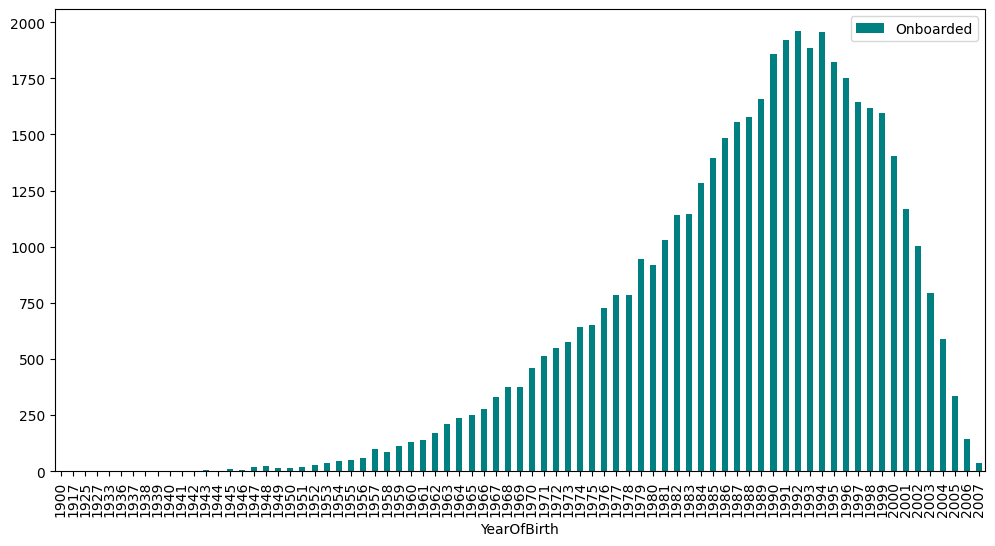

In [11]:


# --- 4) Agrupar por rango de edad y Transacting
counts = (df.groupby(['YearOfBirth','Transacting'])
                  .size()
                  .reset_index(name='n_usuarios'))

# --- 5) Pivot para gráfico
pivot = counts.pivot(index='YearOfBirth', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']


# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)


pivot.head(20)



#Estadística Descriptiva


## #Usuarios por mes

/tmp/ipython-input-3547179709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['YMD'] = pd.to_datetime(df['YMD'], errors='coerce')
/tmp/ipython-input-3547179709.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['year_month'] = df2['YMD'].dt.to_period('M').astype(str)


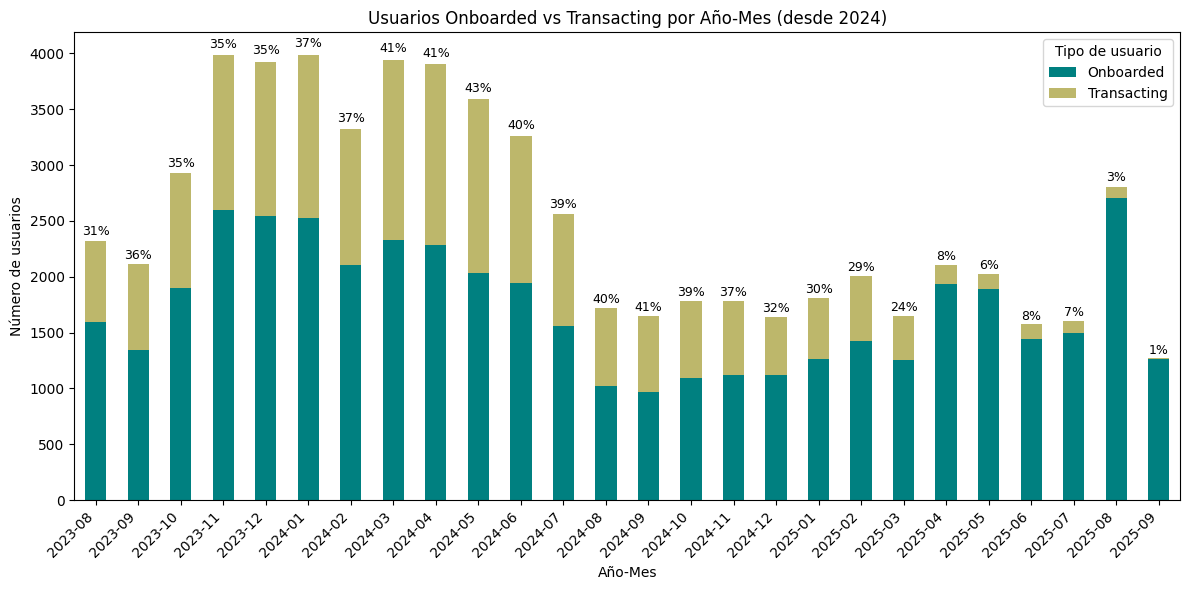

In [12]:


# --- 1) Asegura que la columna YMD sea datetime
df['YMD'] = pd.to_datetime(df['YMD'], errors='coerce')

# --- 1b) Filtrar solo fechas desde enero 2024
df2 = df[df['YMD'] >= "2023-08-01"]

# --- 2) Crea columna Año-Mes (YYYY-MM)
df2['year_month'] = df2['YMD'].dt.to_period('M').astype(str)

# --- 3) Agrupa por mes y Transacting
counts = (df2.groupby(['year_month','Transacting'])
            .size()
            .reset_index(name='n_usuarios'))

# --- 4) Pivot para graficar
pivot = counts.pivot(index='year_month', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 5) % transaccionales
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas de % (redondeado a 0 decimales)
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"{pct:.0f}%",          # ← redondeado a enteros
            ha='center', va='bottom',
            fontsize=9, color='black'
        )
# --- 8) Detalles del gráfico
plt.title("Usuarios Onboarded vs Transacting por Año-Mes (desde 2024)")
plt.xlabel("Año-Mes")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()

##Top 10 Entidades con más usuarios

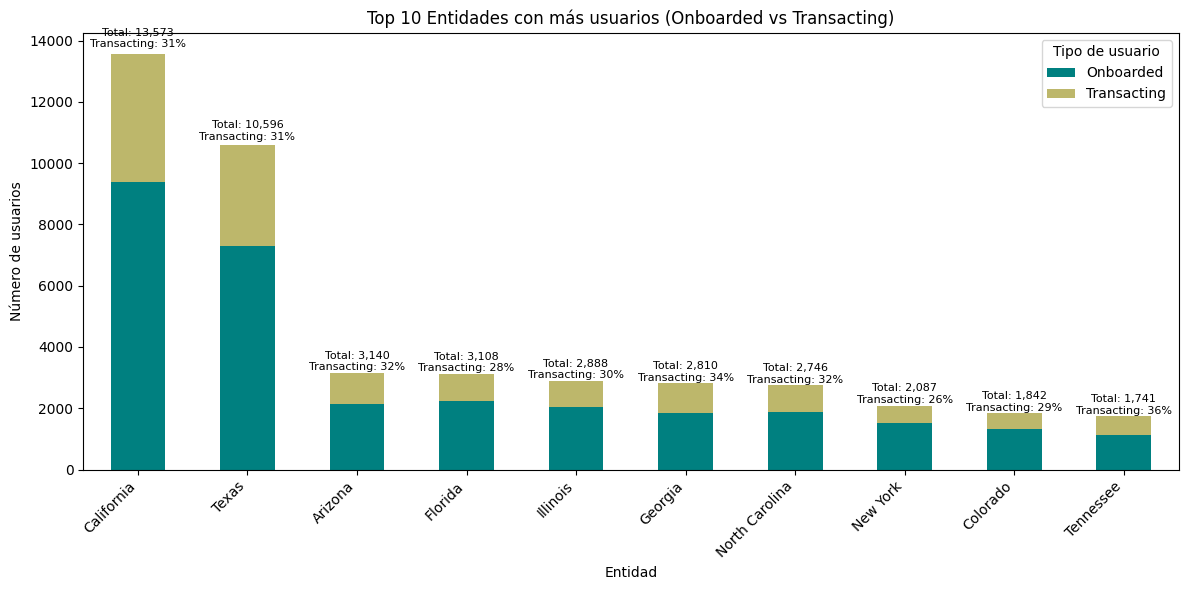

In [13]:
import matplotlib.pyplot as plt

# --- 3) Agrupa por estado y Transacting
counts = (df.groupby(['state_name','Transacting'])
            .size()
            .reset_index(name='n_usuarios'))

# --- 4) Pivot para graficar
pivot = counts.pivot(index='state_name', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 5) Calcula % transacting por estado
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 5b) Ordena por total y selecciona top 10
pivot['Total'] = pivot['Onboarded'] + pivot['Transacting']
pivot = pivot.sort_values('Total', ascending=False).head(10)

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas detalladas
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",  # formato con comas
            ha='center', va='bottom',
            fontsize=8,   # ajusta aquí el tamaño de letra
            color='black'
        )

# --- 8) Detalles del gráfico
plt.title("Top 10 Entidades con más usuarios (Onboarded vs Transacting)")
plt.xlabel("Entidad")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()

##Mapa geográfico del # usuarios por codigo postal

In [14]:
import pydeck as pdk
import pandas as pd

# Agrupa por ZIP
zip_group = df.groupby("postal_code").agg({
    "lat":"mean",
    "lng":"mean",
    "AccountUuid":"count"
}).reset_index().rename(columns={"AccountUuid":"count"})

# Capa de columnas (barras 3D)
layer = pdk.Layer(
    "ColumnLayer",
    data=zip_group,
    get_position=["lng", "lat"],
    get_elevation="count",
    elevation_scale=2000,
    radius=3000,
    get_fill_color="[255, count*10, 0]",
    pickable=True,
    auto_highlight=True,
)

view_state = pdk.ViewState(latitude=39.5, longitude=-98.35, zoom=3.4, pitch=30)

r = pdk.Deck(layers=[layer],
             initial_view_state=view_state,
             map_provider="carto",   # opciones: 'carto', 'mapbox'
             map_style="light",       # carto: 'light', 'dark', 'voyager', 'positron'
             tooltip={"text": "ZIP: {postal_code}\nUsuarios: {count}"})
r.to_html("mapa.html")



<IPython.core.display.Javascript object>

##Usuarios Onboarded vs Transacting por Rango de Edad

/tmp/ipython-input-3105705881.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (df_age.groupby(['RangoEdad','Transacting'])


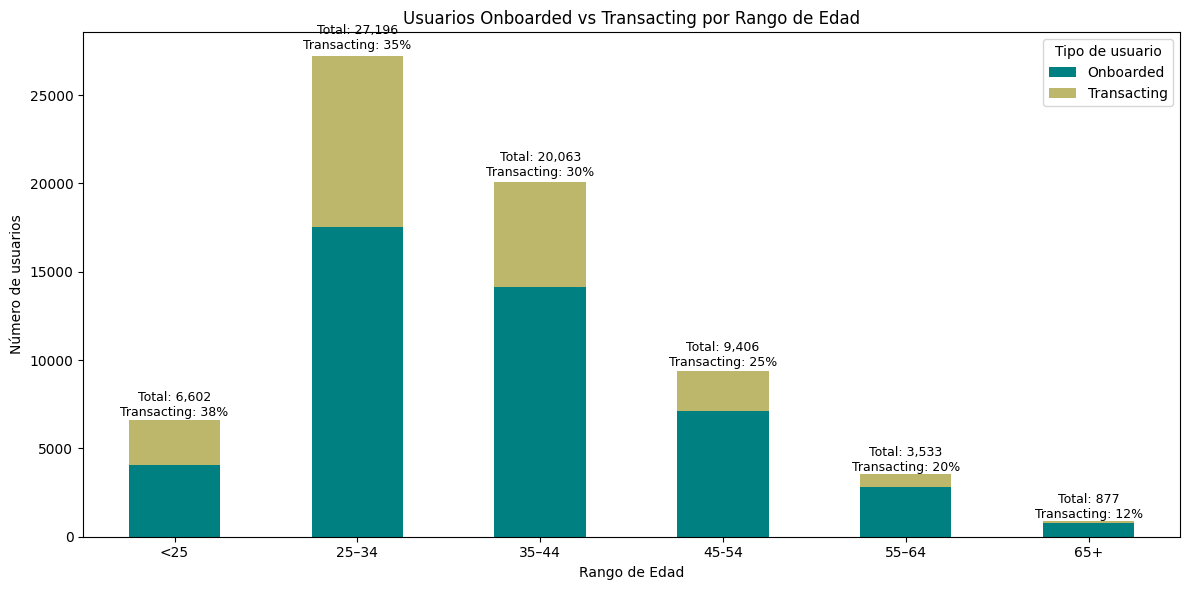

In [15]:

# --- 1) Año actual
year_now = pd.Timestamp.now().year

# --- 2) Calcular edad y filtrar outliers
df_age = df.copy()
df_age['Edad'] = year_now - df_age['YearOfBirth']
df_age = df_age[df_age['YearOfBirth'] != 1900]  # excluir outlier

# --- 3) Definir rangos de edad
bins = [0, 24, 34, 44, 54,64, 120]  # puedes ajustar el último valor
labels = ['<25','25–34','35–44','45-54','55–64','65+']
df_age['RangoEdad'] = pd.cut(df_age['Edad'], bins=bins, labels=labels, right=True)

# --- 4) Agrupar por rango de edad y Transacting
counts = (df_age.groupby(['RangoEdad','Transacting'])
                  .size()
                  .reset_index(name='n_usuarios'))

# --- 5) Pivot para gráfico
pivot = counts.pivot(index='RangoEdad', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 6) % transaccionales
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas detalladas
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",  # formato con comas
            ha='center', va='bottom',
            fontsize=9,   # ajusta aquí el tamaño de letra
            color='black'
        )
# --- 9) Detalles
plt.title("Usuarios Onboarded vs Transacting por Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()


##Distribución % de Usuarios Onboarded vs Transacting por Rango de Edad y Estado

/tmp/ipython-input-1282436697.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age.groupby(['state_name', 'RangoEdad', 'Transacting'])
/tmp/ipython-input-1282436697.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts.pivot_table(


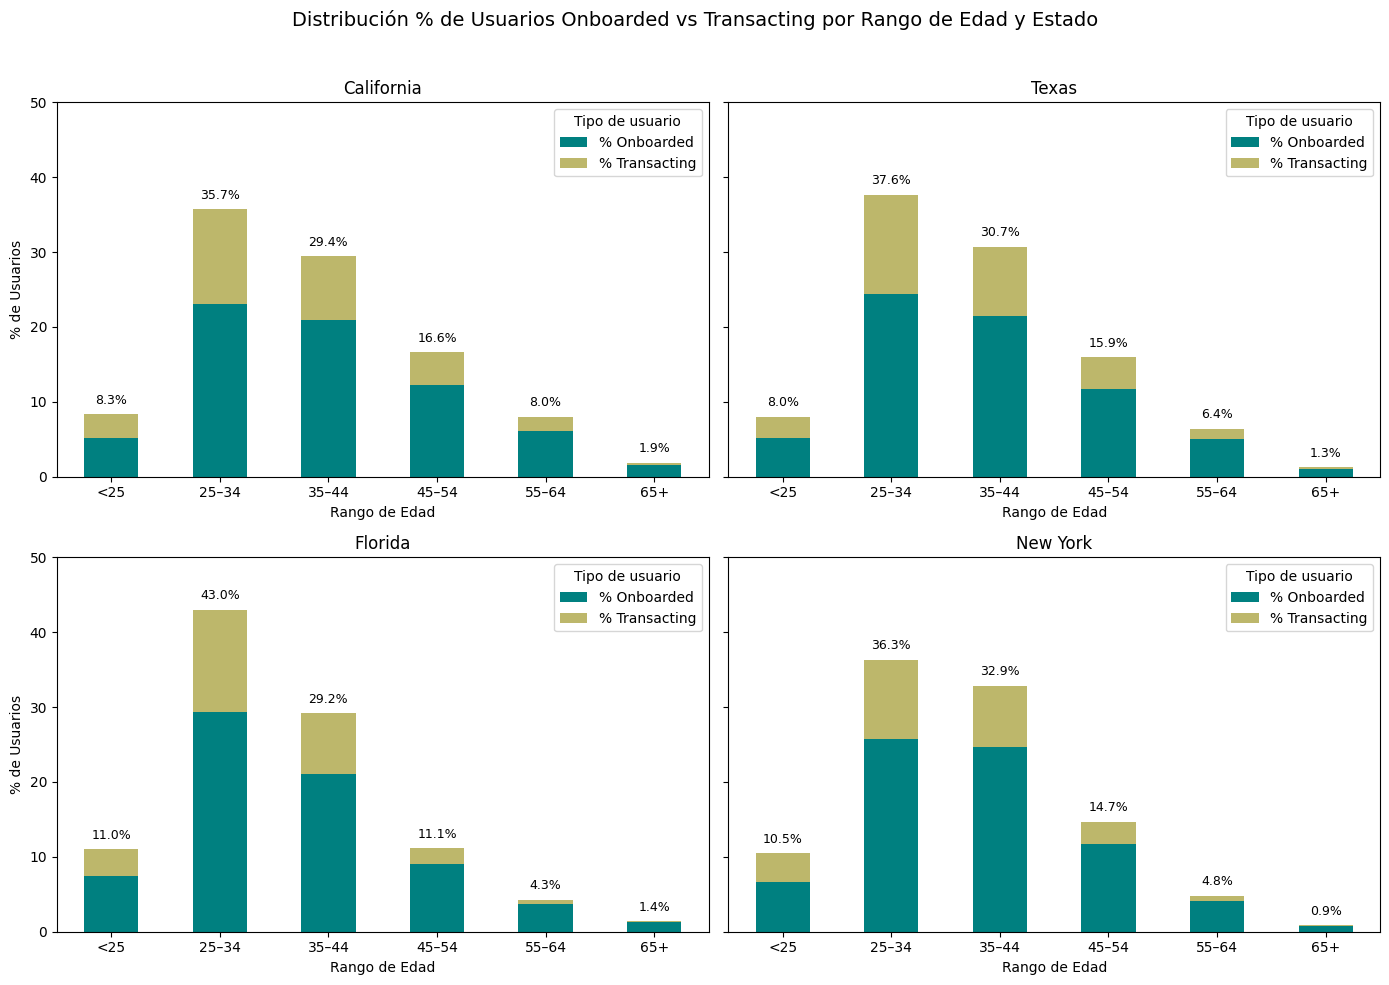

In [16]:

# --- 1) Año actual
year_now = pd.Timestamp.now().year

# --- 2) Calcular edad y filtrar outliers
df_age = df.copy()
df_age['Edad'] = year_now - df_age['YearOfBirth']
df_age = df_age[df_age['YearOfBirth'] != 1900]

# --- 3) Definir rangos de edad
bins = [0, 24, 34, 44, 54, 64, 120]
labels = ['<25','25–34','35–44','45–54','55–64','65+']
df_age['RangoEdad'] = pd.cut(df_age['Edad'], bins=bins, labels=labels, right=True)

# --- 4) Filtrar estados
estados_seleccion = ['California', 'Texas', 'Florida', 'New York']
df_age = df_age[df_age['state_name'].isin(estados_seleccion)]

# --- 5) Agrupar
counts = (
    df_age.groupby(['state_name', 'RangoEdad', 'Transacting'])
    .size()
    .reset_index(name='n_usuarios')
)

# --- 6) Pivot y total por estado
pivot = (
    counts.pivot_table(
        index=['state_name','RangoEdad'],
        columns='Transacting',
        values='n_usuarios',
        fill_value=0
    )
    .reset_index()
)
pivot.columns.name = None
pivot = pivot.rename(columns={0:'Onboarded',1:'Transacting'})

# --- 7) Calcular total y porcentajes dentro de cada estado
pivot['Total'] = pivot['Onboarded'] + pivot['Transacting']
pivot['% Onboarded'] = pivot['Onboarded'] / pivot.groupby('state_name')['Total'].transform('sum') * 100
pivot['% Transacting'] = pivot['Transacting'] / pivot.groupby('state_name')['Total'].transform('sum') * 100

# --- 8) Graficar en % por estado
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=True)
axes = axes.flatten()

for i, estado in enumerate(estados_seleccion):
    subset = pivot[pivot['state_name'] == estado].copy()

    # Asegura orden y presencia de todos los rangos
    subset = (subset.set_index('RangoEdad')
                      .reindex(labels)            # respeta el orden de categorías
                      .fillna({'Onboarded':0, 'Transacting':0, '% Onboarded':0, '% Transacting':0, 'Total':0})
                      .reset_index())

    # Plot apilado en %
    ax = subset[['RangoEdad','% Onboarded','% Transacting']].set_index('RangoEdad') \
         .plot(kind='bar', stacked=True, color=['teal','darkkhaki'], ax=axes[i])

    # Etiqueta dinámica justo arriba de cada barra (% total de ese rango)
    total_pct_col = (subset['% Onboarded'] + subset['% Transacting']).to_numpy()
    for x, h in enumerate(total_pct_col):
        ax.text(x, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, color='black')


    axes[i].set_title(estado)
    axes[i].set_xlabel("Rango de Edad")
    axes[i].set_ylabel("% de Usuarios")
    axes[i].legend(title="Tipo de usuario")
    axes[i].set_xticklabels(labels, rotation=0)
    axes[i].set_ylim(0, 50)  # deja espacio para etiquetas

plt.suptitle("Distribución % de Usuarios Onboarded vs Transacting por Rango de Edad y Estado", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##Distribución de usuarios de distintos atributos

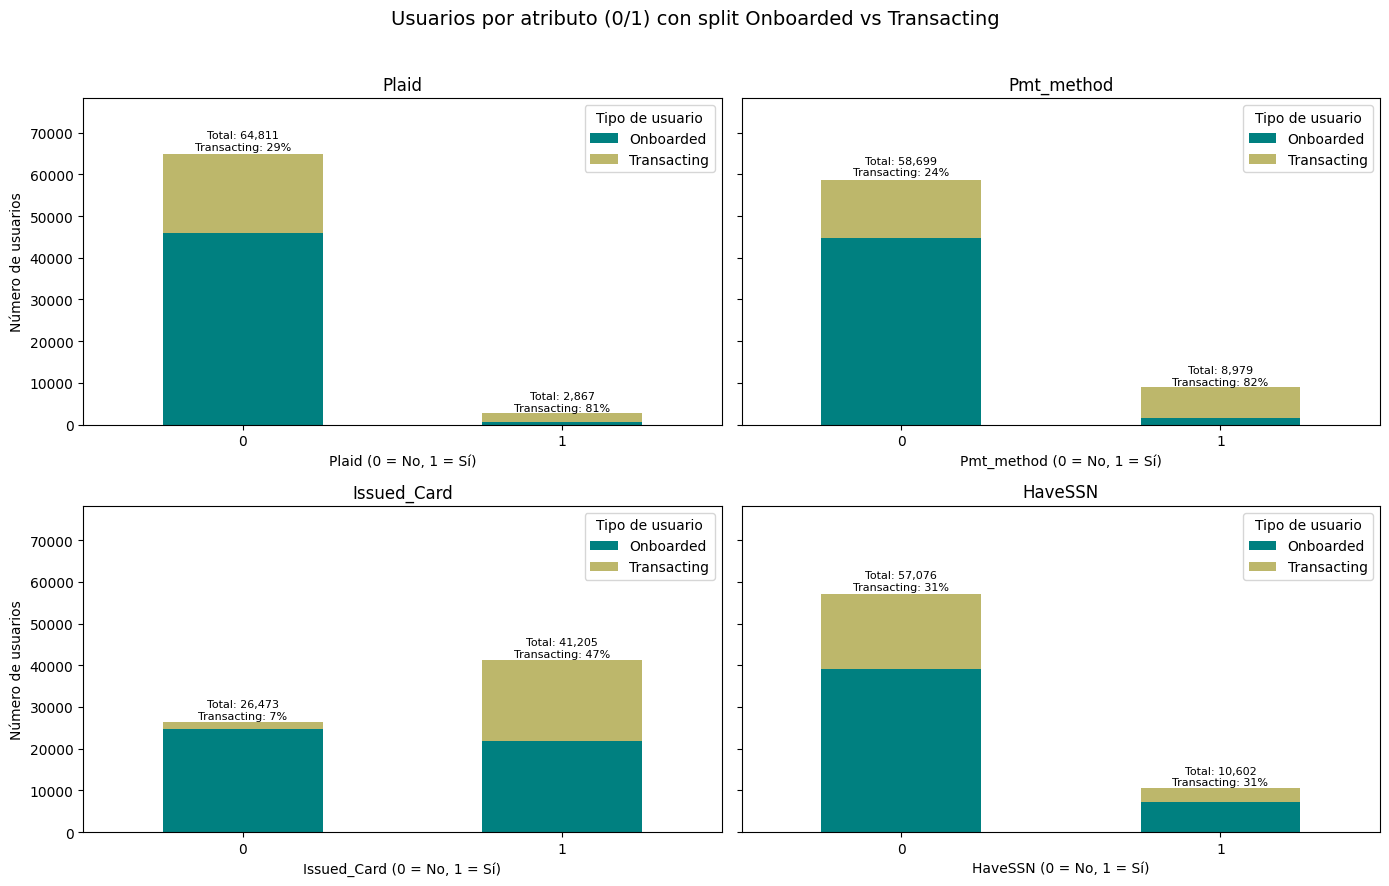

In [17]:


cols = ['Plaid', 'Pmt_method', 'Issued_Card', 'HaveSSN']

def to_binary(series):
    true_set  = {True, 1, 1.0, '1', 'true', 'True', 'yes', 'Yes', 'y', 'Y', 'si', 'Sí', 'SI'}
    false_set = {False, 0, 0.0, '0', 'false', 'False', 'no', 'No', 'n', 'N'}
    def map_val(v):
        if pd.isna(v): return np.nan
        if v in true_set: return 1
        if v in false_set: return 0
        try:
            fv = float(v)
            if fv == 1.0: return 1
            if fv == 0.0: return 0
        except:
            pass
        return np.nan
    return series.apply(map_val)

# --- Normaliza columna Transacting ---
transacting_bin = to_binary(df['Transacting']).astype('Int64')

# --- Crear figura 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    if col not in df.columns:
        ax.axis('off')
        ax.set_title(f"{col} (no existe en df)")
        continue

    # --- Normaliza la variable ---
    col_bin = to_binary(df[col]).astype('Int64')
    mask = col_bin.isin([0,1]) & transacting_bin.isin([0,1])
    dfx = pd.DataFrame({
        col: col_bin[mask].astype(int),
        'Transacting': transacting_bin[mask].astype(int)
    })

    if dfx.empty:
        ax.axis('off')
        ax.set_title(f"{col} (sin datos válidos)")
        continue

    # --- Crosstab ---
    ct = pd.crosstab(dfx[col], dfx['Transacting'])
    for c in [0,1]:
        if c not in ct.columns:
            ct[c] = 0
    for r in [0,1]:
        if r not in ct.index:
            ct.loc[r, :] = 0
    ct = ct.sort_index()[[0,1]]
    ct_plot = ct.rename(columns={0:'Onboarded', 1:'Transacting'})

    # --- Plot apilado ---
    ct_plot.plot(kind='bar', stacked=True, color=['teal','darkkhaki'], edgecolor='none', ax=ax)

    # --- Etiquetas estilo "Total / % Transacting" ---
    for idx, (onb, tra) in enumerate(zip(ct_plot['Onboarded'], ct_plot['Transacting'])):
        total = onb + tra
        pct = (tra / total * 100) if total > 0 else 0
        if total > 0:
            ax.text(
                idx, total + total * 0.01,
                f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",
                ha='center', va='bottom',
                fontsize=8,
                color='black'
            )

    # --- Estilo del subplot ---
    ax.set_title(col)
    ax.set_xlabel(f"{col} (0 = No, 1 = Sí)")
    ax.set_ylabel("Número de usuarios")
    ax.set_xticklabels(['0','1'], rotation=0)
    ax.legend(title="Tipo de usuario", loc="upper right")
    ax.set_ylim(0, ct_plot.values.max().max() * 2)

plt.suptitle("Usuarios por atributo (0/1) con split Onboarded vs Transacting", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##Correlación entre #Usuarios y %de Hispanos por codigo postal

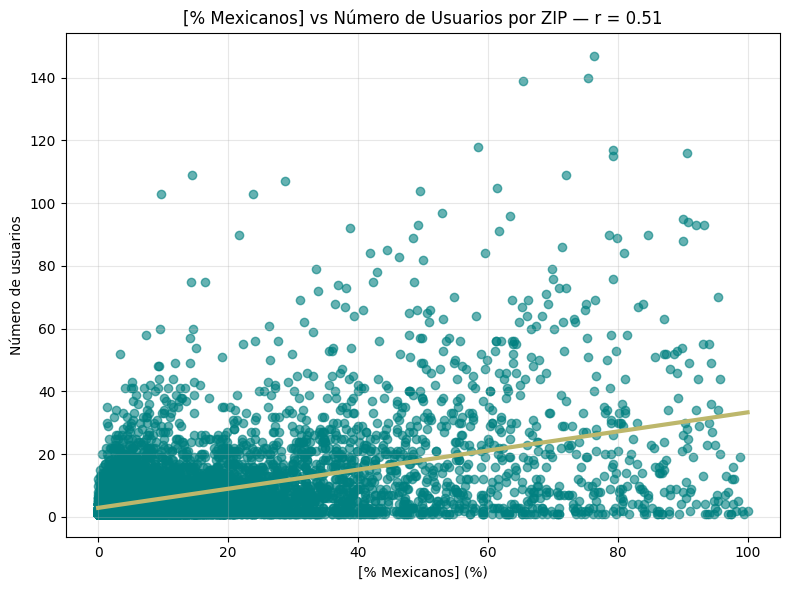

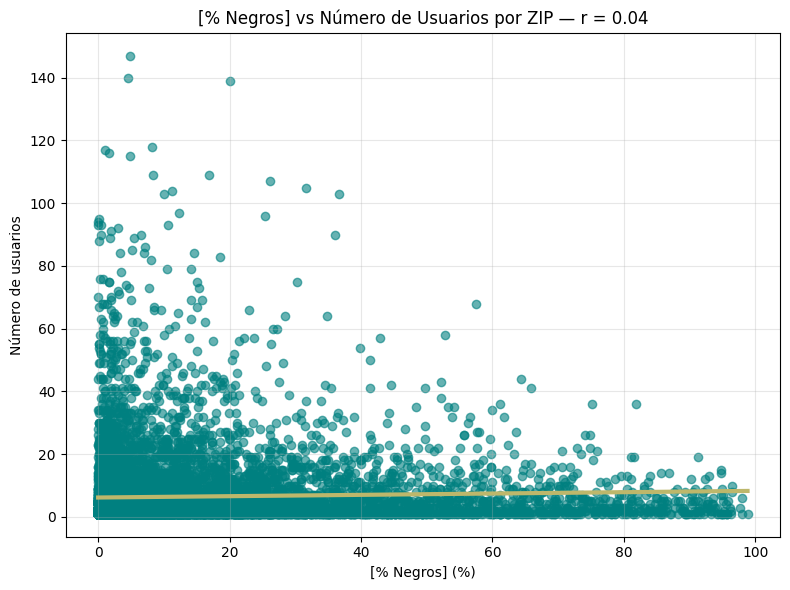

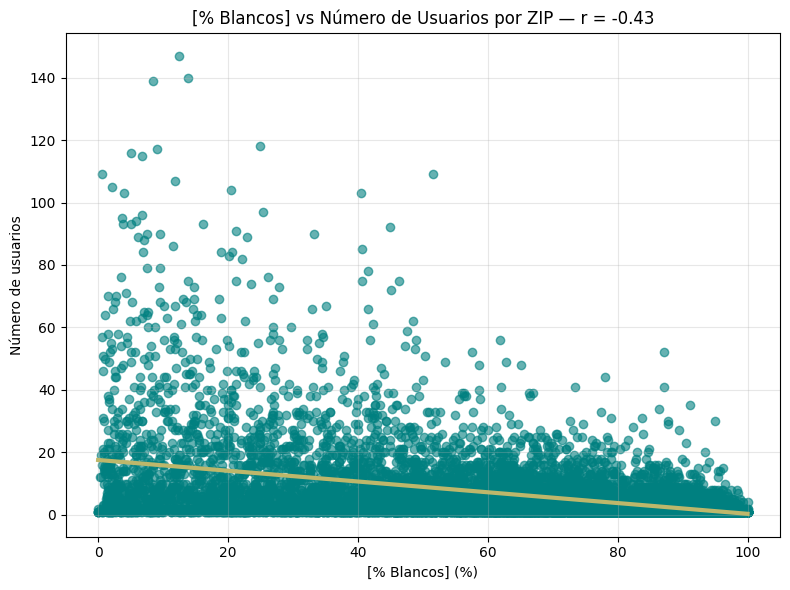

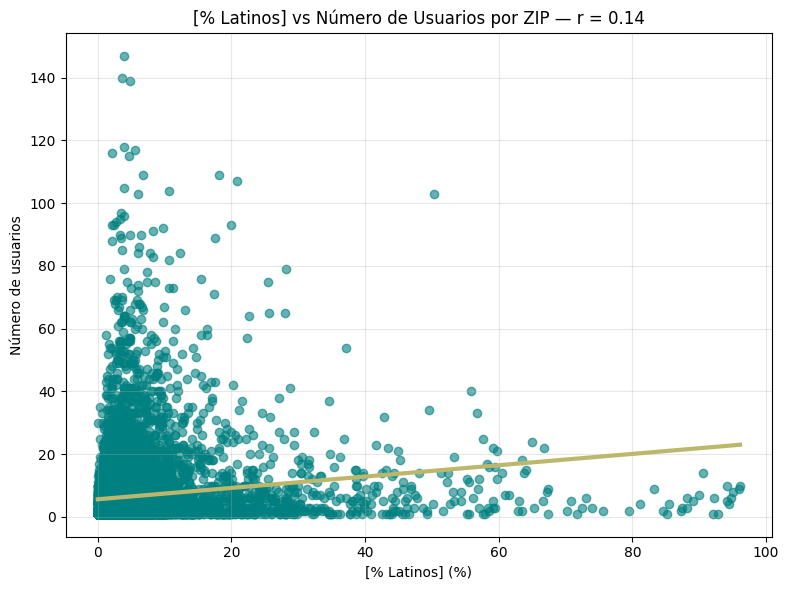

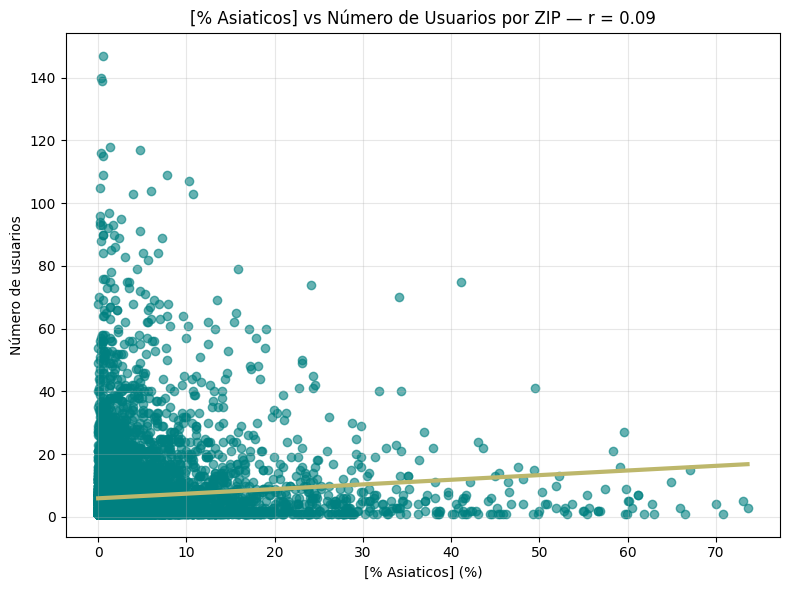

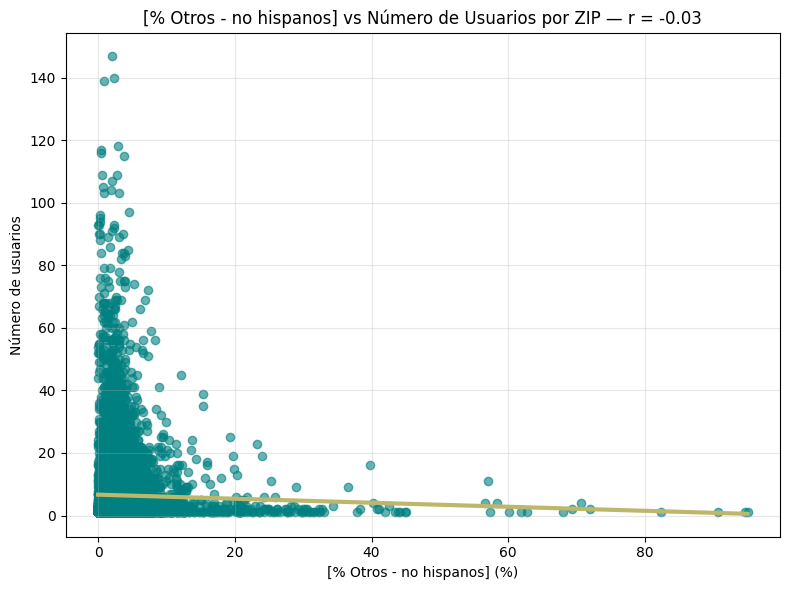

In [19]:

# -----------------------------
# CONFIG
# -----------------------------
# Lista de columnas étnicas EXACTAS (con corchetes)
ETH_COLS = [
    '[% Mexicanos]',
    '[% Negros]',
    '[% Blancos]',
    '[% Latinos]',
    '[% Asiaticos]',
    '[% Otros - no hispanos]'
]

ZIP_COL = 'postal_code'
USER_ID_COL = 'AccountUuid'
STATE_COL = 'state_name'  # si quieres filtrar por estado
STATE_FILTER = None       # por ejemplo: "California" o None para no filtrar
#OUT_DIR = Path("./plots_zip_correlations")
#OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# (Opcional) Filtra por estado
# -----------------------------
df_use = df.copy()
if STATE_FILTER:
    df_use = df_use[df_use[STATE_COL] == STATE_FILTER]

# -----------------------------
# Agrega por ZIP
# - Promedio de % por ZIP
# - Conteo de usuarios por ZIP
# -----------------------------
agg_dict = {col: 'mean' for col in ETH_COLS}
agg_dict[USER_ID_COL] = 'count'

zip_group = (
    df_use
    .groupby(ZIP_COL, dropna=False)
    .agg(agg_dict)
    .rename(columns={USER_ID_COL: 'user_count'})
    .reset_index()
)

# Convierte 0..1 -> 0..100 si aplica
for col in ETH_COLS:
    col_vals = zip_group[col].dropna()
    if len(col_vals) > 0 and col_vals.max() <= 1.5:  # heurística
        zip_group[col] = zip_group[col] * 100.0

# Limpieza básica
zip_group = zip_group.replace([np.inf, -np.inf], np.nan).dropna(subset=['user_count'])

# -----------------------------
# Función: scatter con recta y r
# -----------------------------
def fit_line_and_r(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return (np.nan, np.nan), np.nan, x, y
    # recta
    coef = np.polyfit(x, y, 1)     # [pendiente, intercepto]
    yhat = np.polyval(coef, x)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    # convierte r2 en r con el signo de la pendiente (ilustrativo)
    r_signed = np.sign(coef[0]) * np.sqrt(r2) if np.isfinite(r2) else np.nan
    return coef, r_signed, x, y

def plot_ethnicity_scatter(df_zip, eth_col):
    x = df_zip[eth_col].values
    y = df_zip['user_count'].values

    coef, r_signed, x_, y_ = fit_line_and_r(x, y)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_, y_, alpha=0.6, color="teal")
    if np.all(np.isfinite(coef)):
        xx = np.linspace(np.nanmin(x_), np.nanmax(x_), 100)
        yy = np.polyval(coef, xx)
        plt.plot(xx, yy, color="darkkhaki", linewidth=3)

    title_r = f"r = {r_signed:.2f}" if np.isfinite(r_signed) else "r = N/A"
    state_txt = f" ({STATE_FILTER})" if STATE_FILTER else ""
    plt.title(f"{eth_col} vs Número de Usuarios por ZIP{state_txt} — {title_r}")
    plt.xlabel(f"{eth_col} (%)")
    plt.ylabel("Número de usuarios")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

# -----------------------------
# Genera un gráfico por etnia
# -----------------------------
for col in ETH_COLS:
    if col in zip_group.columns:
        plot_ethnicity_scatter(zip_group, col)
    else:
        print(f"Columna no encontrada y se omite: {col}")


#Tratamiento de Variables

In [22]:


# -----------------------------
# 0) Config (tus columnas)
# -----------------------------
ETH_COLS = ['[% Mexicanos]','[% Negros]','[% Blancos]','[% Latinos]','[% Asiaticos]','[% Otros - no hispanos]']

def _renormalize_rows(M: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """Recorta a [0,1], renormaliza filas para que sumen 1 (si suma>eps); si no, reparte uniforme."""
    M = M.clip(lower=0.0, upper=1.0)
    s = M.sum(axis=1).values
    out = M.copy()
    ok = s > eps
    out.loc[ok, :] = out.loc[ok, :].div(s[ok], axis=0)
    if (~ok).any():
        k = M.shape[1]
        out.loc[~ok, :] = 1.0 / k
    return out

def prepare_dataset(df):
    df_ = df.copy()

    # --- Fechas coherentes
    df_['Creation_date'] = pd.to_datetime(df_['Creation_date'], errors='coerce')
    df_['YMD'] = pd.to_datetime(df_['YMD'], errors='coerce')

    # --- Target en binario (0/1)
    df_['Transacting'] = df_['Transacting'].astype(float).fillna(0).astype(int)

    # --- Edad a partir de Creation_date (evita fuga usando año de creación)
    year_created = df_['Creation_date'].dt.year
    df_['age'] = (year_created - df_['YearOfBirth']).clip(lower=18, upper=90)

    # --- Densidad (log1p para sesgo)
    df_['density_log1p'] = np.log1p(df_['density'])

    # --- ETNIAS: imputación por estado y renormalización ---
    # (Si tus etnias ya están en 0..1, el bloque siguiente mantiene eso;
    # si alguna estuviera en 0..100, la convertimos primero.)
    for c in ETH_COLS:
        if df_[c].dropna().max() > 1.5:  # heuristic: si hay valores >1.5 asumimos 0..100
            df_[c] = df_[c] / 100.0

    # Medianas por estado
    state_meds = df_.groupby('state_name')[ETH_COLS].median(numeric_only=True)

    # Imputación por fila usando mediana del estado; fallback a mediana global
    global_med = df_[ETH_COLS].median(numeric_only=True)
    def _fill_eth_row(row):
        if row[ETH_COLS].isna().any():
            s = row['state_name']
            if s in state_meds.index:
                row[ETH_COLS] = row[ETH_COLS].fillna(state_meds.loc[s])
            if row[ETH_COLS].isna().any():
                row[ETH_COLS] = row[ETH_COLS].fillna(global_med)
        return row

    df_[ETH_COLS] = df_.apply(_fill_eth_row, axis=1)[ETH_COLS]

    # Renormaliza por fila (mantiene naturaleza composicional)
    df_[ETH_COLS] = _renormalize_rows(df_[ETH_COLS])

    # --- HaveSSN → binario 0/1 (no imputamos aquí)
    df_['HaveSSN_bin'] = (
        df_['HaveSSN'].astype(str).str.strip().str.lower()
        .isin(['1','true','t','yes','y','si','sí'])
        .astype('int8')
    )

    # --- Señales de calendario (sin one-hot aquí)
    df_['month'] = df_['Creation_date'].dt.month.astype('Int16')
    df_['dow']   = df_['Creation_date'].dt.dayofweek.astype('Int16')

    # --- Coerciones suaves a numérico (sin imputar)
    for c in ['lat','lng','Issued_Card','Plaid','Pmt_method']:
        df_[c] = pd.to_numeric(df_[c], errors='coerce')

    # --- Selección de columnas de FEATURES (sin codificar aún)
    num_base = [
        'age','density_log1p','lat','lng',
        'Issued_Card','Plaid','Pmt_method',
        'month','dow'
    ] + ETH_COLS + ['HaveSSN_bin']

    cat_low   = ['state_name']          # one-hot después (solo en train)
    high_card = ['city','postal_code']  # freq/target encoding después (solo en train)

    feature_cols = num_base + cat_low + high_card

    # Subconjunto final (dejamos Creation_date y Transacting para split y target)
    out = df_[feature_cols + ['Creation_date','Transacting']].copy()
    return out, num_base, cat_low, high_card



In [23]:
# 1) Preparar variables (aún sin encodings/imputaciones)
prepared_df, num_base, cat_low, high_card = prepare_dataset(df)

# 2) Máscaras de tiempo (split sin fuga)
train_mask = prepared_df['Creation_date'] <  pd.Timestamp('2025-01-01')
test_mask  = (prepared_df['Creation_date'] >= pd.Timestamp('2025-01-01')) & \
             (prepared_df['Creation_date'] <  pd.Timestamp('2026-01-01'))

# 3) Particiones
X_train = prepared_df.loc[train_mask].drop(columns=['Creation_date','Transacting'])
y_train = prepared_df.loc[train_mask, 'Transacting'].values.astype(int)

X_test  = prepared_df.loc[test_mask].drop(columns=['Creation_date','Transacting'])
y_test  = prepared_df.loc[test_mask, 'Transacting'].values.astype(int)

print(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())


(51158, 19) (16520, 19) 0.3748191876148403 0.12487893462469733


#Regresión Logistica

In [26]:


# ------------- Encoders auxiliares -------------


class FreqEncoder(BaseEstimator, TransformerMixin):
    """Frequency encoding (proporción de cada categoría)."""
    def __init__(self, cols):
        self.cols = cols
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X
        for c in self.cols:
            vc = X[c].value_counts(dropna=False)
            self.maps_[c] = (vc / vc.sum())
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X.copy()
        outs = []
        for c in self.cols:
            outs.append(X[c].map(self.maps_[c]).astype('float64').fillna(0.0).to_numpy().reshape(-1,1))
        return np.hstack(outs)

# ------------- Column sets para logística -------------
ETH_COLS = ['[% Mexicanos]','[% Negros]','[% Blancos]','[% Latinos]','[% Asiaticos]','[% Otros - no hispanos]']

# Para modelos lineales/MLP quitamos una etnia (referencia) para evitar colinealidad
num_linear = [c for c in num_base if c != '[% Otros - no hispanos]']  # usa Blanco como referencia

pre_linear = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler())
        ]), num_linear),
        ('ohe_state', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_low),                     # ['state_name']
        ('freq', FreqEncoder(high_card), high_card)  # ['city','postal_code']
    ],
    remainder='drop'
)

logit = Pipeline([
    ('pre', pre_linear),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # ayuda si hay desbalance
        C=1.0,
        solver='lbfgs'             # 'saga' si el dataset es muy grande o quieres l1/l2 elástica
    ))
])

# --------- Entrena solo con train ---------
logit.fit(X_train, y_train)

# --------- Evalúa en test (2025) ---------
p_test = logit.predict_proba(X_test)[:,1]
y_pred05 = (p_test >= 0.50).astype(int)

metrics = {
    'ROC_AUC': roc_auc_score(y_test, p_test),
    'PR_AUC' : average_precision_score(y_test, p_test),
    'F1@0.5' : f1_score(y_test, y_pred05),
    'Brier'  : brier_score_loss(y_test, p_test),
    'Prevalencia_test': float(np.mean(y_test))
}
print(pd.Series(metrics).round(4))
print("\nReporte @0.5:\n", classification_report(y_test, y_pred05, digits=3))
print("Matriz de confusión @0.5:\n", confusion_matrix(y_test, y_pred05))


ROC_AUC             0.9277
PR_AUC              0.6032
F1@0.5              0.5782
Brier               0.0823
Prevalencia_test    0.1249
dtype: float64

Reporte @0.5:
               precision    recall  f1-score   support

           0      0.971     0.856     0.910     14457
           1      0.447     0.818     0.578      2063

    accuracy                          0.851     16520
   macro avg      0.709     0.837     0.744     16520
weighted avg      0.905     0.851     0.868     16520

Matriz de confusión @0.8:
 [[12372  2085]
 [  376  1687]]


#Random Forest

In [27]:

# -------------------- Frequency Encoder simple --------------------
class FreqEncoder(BaseEstimator, TransformerMixin):
    """Frequency encoding (proporción de ocurrencia por categoría)."""
    def __init__(self, cols):
        self.cols = cols
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X
        for c in self.cols:
            vc = X[c].value_counts(dropna=False)
            self.maps_[c] = (vc / vc.sum())
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X.copy()
        outs = []
        for c in self.cols:
            outs.append(X[c].map(self.maps_[c]).astype('float64').fillna(0.0).to_numpy().reshape(-1,1))
        return np.hstack(outs)

# -------------------- Preprocesamiento para árboles --------------------
# En árboles podemos conservar TODAS las columnas étnicas (num_base ya las incluye).
numeric_tree = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median'))
])

# Compatibilidad con distintas versiones de sklearn (sparse_output vs sparse)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_low = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', ohe)
])

pre_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_tree, num_base),        # numéricas (incluye etnias)
        ('ohe_state', categorical_low, cat_low),# ['state_name']
        ('freq', FreqEncoder(high_card), high_card)  # ['city','postal_code']
    ],
    remainder='drop'
)

# -------------------- Modelo Random Forest --------------------
rf = Pipeline(steps=[
    ('pre', pre_tree),
    ('clf', RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight='balanced_subsample',  # ayuda con desbalance
        random_state=42
    ))
])

# -------------------- Entrenamiento y evaluación --------------------
rf.fit(X_train, y_train)

p_test = rf.predict_proba(X_test)[:, 1]
y_pred05 = (p_test >= 0.5).astype(int)

metrics = {
    'ROC_AUC': roc_auc_score(y_test, p_test),
    'PR_AUC': average_precision_score(y_test, p_test),
    'F1@0.5': f1_score(y_test, y_pred05),
    'Brier': brier_score_loss(y_test, p_test),
    'Prevalencia_test': float(np.mean(y_test))
}
print(pd.Series(metrics).round(4))

print("\nReporte @0.5:\n", classification_report(y_test, y_pred05, digits=3))
print("Matriz de confusión @0.5:\n", confusion_matrix(y_test, y_pred05))

ROC_AUC             0.9292
PR_AUC              0.6062
F1@0.5              0.5692
Brier               0.0755
Prevalencia_test    0.1249
dtype: float64

Reporte @0.5:
               precision    recall  f1-score   support

           0      0.948     0.909     0.928     14457
           1      0.506     0.651     0.569      2063

    accuracy                          0.877     16520
   macro avg      0.727     0.780     0.749     16520
weighted avg      0.893     0.877     0.883     16520

Matriz de confusión @0.5:
 [[13147  1310]
 [  721  1342]]


In [28]:
# Recuperar nombres de features tras el preprocesamiento
pre = rf.named_steps['pre']
feat_names = []

# 1) num_base (mismo orden)
feat_names += list(num_base)

# 2) state_name (OHE)
ohe_state = pre.named_transformers_['ohe_state'].named_steps['ohe']
feat_names += list(ohe_state.get_feature_names_out(['state_name']))

# 3) freq enc para city y postal_code
feat_names += ['city_freq', 'postal_code_freq']

# Importancias del bosque
importances = rf.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}) \
         .sort_values('importance', ascending=False)
imp_df.head(25)

,feature,importance
6,Pmt_method,0.183331
4,Issued_Card,0.168695
0,age,0.070132
7,month,0.049117
8,dow,0.041528
9,[% Mexicanos],0.039343
1,density_log1p,0.039133
5,Plaid,0.039032
11,[% Blancos],0.038962
3,lng,0.038542


#XGboost

In [40]:
# ============================================================================
# Preprocesamiento para modelos de árboles (reusa lo mismo que en RF)
# ============================================================================

class FreqEncoder(BaseEstimator, TransformerMixin):
    """Frequency encoding (proporción por categoría)."""
    def __init__(self, cols):
        self.cols = cols
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X
        for c in self.cols:
            vc = X[c].value_counts(dropna=False)
            self.maps_[c] = (vc / vc.sum())
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X.copy()
        outs = []
        for c in self.cols:
            outs.append(X[c].map(self.maps_[c]).astype('float64').fillna(0.0).to_numpy().reshape(-1,1))
        return np.hstack(outs)

# OneHotEncoder compat (según versión de sklearn)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_tree = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median'))
])
categorical_low = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', ohe)
])

pre_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_tree, num_base),          # numéricas (incluye etnias)
        ('ohe_state', categorical_low, cat_low),  # ['state_name']
        ('freq', FreqEncoder(high_card), high_card)  # ['city','postal_code']
    ],
    remainder='drop'
)

# ============================================================================
# Split temporal interno para early stopping (dentro de TRAIN)
# Tomamos el último 10% del TRAIN (ordenado por fecha) como validación
# ============================================================================

# 'prepared_df' ya existe por tu prepare_dataset(df)
train_dates = prepared_df.loc[prepared_df['Creation_date'] < pd.Timestamp('2025-01-01'), 'Creation_date']
order_within_train = np.argsort(train_dates.values)                 # posiciones temporales dentro de train
cut = int(0.9 * len(order_within_train))

# Use boolean masks for consistent splitting
tr_mask_within_train = np.zeros(len(train_dates), dtype=bool)
tr_mask_within_train[order_within_train[:cut]] = True
va_mask_within_train = np.zeros(len(train_dates), dtype=bool)
va_mask_within_train[order_within_train[cut:]] = True

X_tr = X_train.iloc[tr_mask_within_train]
y_tr = y_train[tr_mask_within_train]
X_va = X_train.iloc[va_mask_within_train]
y_va = y_train[va_mask_within_train]


# Manejo de desbalance para XGB
pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
scale_pos_weight = max(1.0, neg / max(pos, 1))

# ============================================================================
# Modelo XGBoost
# ============================================================================

from xgboost.callback import EarlyStopping

xgb = Pipeline(steps=[
    ('pre', pre_tree),
    ('clf', XGBClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        tree_method='hist',
        random_state=42,
        # métrica interna para early stopping (no afecta tus métricas externas)
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight
    ))
])

# Entrenamiento con early stopping using the validation temporal
# Removed EarlyStopping due to incompatibility with installed xgboost version
xgb.fit(
    X_tr, y_tr,
    # clf__eval_set=[(X_va, y_va)], # Removed eval_set
    # clf__callbacks=[early_stopping] # Removed callbacks
)

# ============================================================================
# Evaluación en TEST 2025 (umbral 0.5)
# ============================================================================

p_test_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred05_xgb = (p_test_xgb >= 0.5).astype(int)

metrics_xgb = {
    'ROC_AUC': roc_auc_score(y_test, p_test_xgb),
    'PR_AUC' : average_precision_score(y_test, p_test_xgb),
    'F1@0.5' : f1_score(y_test, y_pred05_xgb),
    'Brier'  : brier_score_loss(y_test, p_test_xgb),
    'Prevalencia_test': float(np.mean(y_test))
}
print(pd.Series(metrics_xgb).round(4))

print("\nReporte @0.5:\n", classification_report(y_test, y_pred05_xgb, digits=3))
print("Matriz de confusión @0.5:\n", confusion_matrix(y_test, y_pred05_xgb))

ROC_AUC             0.9278
PR_AUC              0.5985
F1@0.5              0.5774
Brier               0.0811
Prevalencia_test    0.1249
dtype: float64

Reporte @0.5:
               precision    recall  f1-score   support

           0      0.958     0.888     0.921     14457
           1      0.480     0.726     0.577      2063

    accuracy                          0.867     16520
   macro avg      0.719     0.807     0.749     16520
weighted avg      0.898     0.867     0.878     16520

Matriz de confusión @0.5:
 [[12832  1625]
 [  566  1497]]


In [41]:
# Recuperar nombres de features tras el preprocesamiento
pre = xgb.named_steps['pre']
feat_names = []

# 1) num_base
feat_names += list(num_base)

# 2) state_name (OHE)
ohe_state = pre.named_transformers_['ohe_state'].named_steps['ohe']
feat_names += list(ohe_state.get_feature_names_out(['state_name']))

# 3) freq encoders
feat_names += ['city_freq', 'postal_code_freq']

importances = xgb.named_steps['clf'].feature_importances_
imp_xgb = pd.DataFrame({'feature': feat_names, 'importance': importances}) \
          .sort_values('importance', ascending=False)
imp_xgb.head(25)


,feature,importance
4,Issued_Card,0.380559
6,Pmt_method,0.202755
5,Plaid,0.071263
15,HaveSSN_bin,0.024708
38,state_name_Missouri,0.010032
26,state_name_Hawaii,0.007356
50,state_name_South Carolina,0.007307
48,state_name_Oregon,0.007070
32,state_name_Kentucky,0.006799
53,state_name_Texas,0.006721


#Red Neuronal

In [43]:

# -------------------- Frequency Encoder (si no está definido) --------------------
class FreqEncoder(BaseEstimator, TransformerMixin):
    """Frequency encoding (proporción por categoría)."""
    def __init__(self, cols):
        self.cols = cols
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X
        for c in self.cols:
            vc = X[c].value_counts(dropna=False)
            self.maps_[c] = (vc / vc.sum())
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X.copy()
        outs = []
        for c in self.cols:
            outs.append(X[c].map(self.maps_[c]).astype('float64').fillna(0.0).to_numpy().reshape(-1,1))
        return np.hstack(outs)

# -------------------- Column sets para MLP/Lineales --------------------
ETH_COLS = ['[% Mexicanos]','[% Negros]','[% Blancos]','[% Latinos]','[% Asiaticos]','[% Otros - no hispanos]']

# Quitamos UNA etnia (p. ej. Blancos) para evitar multicolinealidad en composiciones
num_linear = [c for c in num_base if c != '[% Otros - no hispanos]']

# OneHotEncoder compat (según versión sklearn)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

pre_linear = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler())
        ]), num_linear),
        ('ohe_state', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', ohe)
        ]), cat_low),                     # ['state_name']
        ('freq', FreqEncoder(high_card), high_card)  # ['city','postal_code']
    ],
    remainder='drop'
)

# -------------------- Modelo MLP --------------------
mlp = Pipeline(steps=[
    ('pre', pre_linear),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        alpha=1e-4,                 # L2
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,        # usa un holdout interno del 10% del train (estratificado aleatorio)
        n_iter_no_change=15,
        random_state=42
    ))
])

# -------------------- Entrenamiento y evaluación (@0.5) --------------------
mlp.fit(X_train, y_train)

p_test_mlp = mlp.predict_proba(X_test)[:, 1]
y_pred05_mlp = (p_test_mlp >= 0.5).astype(int)

metrics_mlp = {
    'ROC_AUC': roc_auc_score(y_test, p_test_mlp),
    'PR_AUC' : average_precision_score(y_test, p_test_mlp),
    'F1@0.5' : f1_score(y_test, y_pred05_mlp),
    'Brier'  : brier_score_loss(y_test, p_test_mlp),
    'Prevalencia_test': float(np.mean(y_test))
}
print(pd.Series(metrics_mlp).round(4))

print("\nReporte @0.5:\n", classification_report(y_test, y_pred05_mlp, digits=3))
print("Matriz de confusión @0.5:\n", confusion_matrix(y_test, y_pred05_mlp))

ROC_AUC             0.9280
PR_AUC              0.5963
F1@0.5              0.5006
Brier               0.0715
Prevalencia_test    0.1249
dtype: float64

Reporte @0.5:
               precision    recall  f1-score   support

           0      0.923     0.955     0.938     14457
           1      0.581     0.440     0.501      2063

    accuracy                          0.890     16520
   macro avg      0.752     0.697     0.720     16520
weighted avg      0.880     0.890     0.884     16520

Matriz de confusión @0.5:
 [[13803   654]
 [ 1156   907]]


#Comparativo

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    brier_score_loss, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """Evalúa un pipeline sklearn en test y devuelve dict con métricas y confusión."""
    p = model.predict_proba(X_test)[:, 1]
    y_pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        'model': name,
        'ROC_AUC': roc_auc_score(y_test, p),
        'PR_AUC': average_precision_score(y_test, p),
        f'F1@{threshold}': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'Brier': brier_score_loss(y_test, p),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Positives': int(y_test.sum()),
        'N': len(y_test)
    }, p  # también regreso las probabilidades para comparativas adicionales

def sweep_thresholds(y_true, y_prob, ts=np.linspace(0.05, 0.95, 19)):
    """Tabla con precision/recall/F1 y confusión por varios umbrales."""
    rows = []
    for t in ts:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append({
            'thr': t,
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
        })
    return pd.DataFrame(rows)

def topk_metrics(y_true, y_prob, ks=(0.01, 0.05, 0.10)):
    """Lift y hit-rate para varios top-k (proporciones de población)."""
    out = []
    base = y_true.mean()
    order = np.argsort(-y_prob)
    n = len(y_true)
    for k in ks:
        kk = max(1, int(k * n))
        idx = order[:kk]
        hit = y_true[idx].mean()
        lift = hit / base if base > 0 else np.nan
        out.append({'k_frac': k, 'k_n': kk, 'hit_rate': hit, 'lift': lift})
    return pd.DataFrame(out)


In [49]:
# Registra aquí tus modelos entrenados
models = {
    'Logistic': logit,
    'RandomForest': rf,
    'XGBoost': xgb,
    'MLP': mlp
}

threshold = 0.5
rows = []
probs = {}  # guardamos probabilidades por modelo para top-k o barridos

for name, mdl in models.items():
    m, p = evaluate_model(name, mdl, X_test, y_test, threshold=threshold)
    rows.append(m); probs[name] = p

metrics_df = pd.DataFrame(rows).set_index('model')
metrics_df = metrics_df[['ROC_AUC','PR_AUC',f'F1@{threshold}','Precision','Recall','Brier','TP','FP','TN','FN','Positives','N']]
print(metrics_df.round(4))


              ROC_AUC  PR_AUC  F1@0.5  Precision  Recall   Brier    TP    FP  \
model                                                                          
Logistic       0.9277  0.6032  0.5782     0.4472  0.8177  0.0823  1687  2085   
RandomForest   0.9292  0.6062  0.5692     0.5060  0.6505  0.0755  1342  1310   
XGBoost        0.9278  0.5985  0.5774     0.4795  0.7256  0.0811  1497  1625   
MLP            0.9280  0.5963  0.5006     0.5810  0.4397  0.0715   907   654   

                 TN    FN  Positives      N  
model                                        
Logistic      12372   376       2063  16520  
RandomForest  13147   721       2063  16520  
XGBoost       12832   566       2063  16520  
MLP           13803  1156       2063  16520  


In [46]:
# Compara lift/hit-rate en top 5% para todos
k_list = (0.01, 0.05, 0.10)
topk_tables = {}
for name, p in probs.items():
    topk_tables[name] = topk_metrics(y_test, p, ks=k_list)

# Vista consolidada en una sola tabla (k=5% como ejemplo)
k_sel = 0.05
consol = []
for name, tbl in topk_tables.items():
    row = tbl.loc[np.isclose(tbl['k_frac'], k_sel)].copy()
    row['model'] = name
    consol.append(row[['model','k_n','hit_rate','lift']])
topk_5 = pd.concat(consol).set_index('model').sort_values('lift', ascending=False)
print("\nTop-5% (hit_rate y lift):\n", topk_5.round(3))



Top-5% (hit_rate y lift):
               k_n  hit_rate   lift
model                             
RandomForest  826     0.715  5.730
MLP           826     0.711  5.691
Logistic      826     0.685  5.487
XGBoost       826     0.685  5.487


In [52]:
from sklearn.metrics import precision_recall_curve

target_precision = 0.80
thr_by_model = {}
for name, p in probs.items():
    prec, rec, thr = precision_recall_curve(y_test, p)
    mask = prec[:-1] >= target_precision
    thr_match = thr[mask][0] if mask.any() else 0.5
    thr_by_model[name] = float(thr_match)

print("Umbral para ~≥70% precisión por modelo:\n", pd.Series(thr_by_model))

#aqui respondemos a la pregunta, que umbral necesito para tener un 70% de precisión en transacting

Umbral para ~≥70% precisión por modelo:
 Logistic        0.953682
RandomForest    0.789955
XGBoost         0.928560
MLP             0.843708
dtype: float64


In [50]:
def pretty(df):
    return df.style.format({
        'ROC_AUC':'{:.3f}','PR_AUC':'{:.3f}',f'F1@{threshold}':'{:.3f}',
        'Precision':'{:.3f}','Recall':'{:.3f}','Brier':'{:.4f}'
    })

pretty(metrics_df)


,ROC_AUC,PR_AUC,F1@0.5,Precision,Recall,Brier,TP,FP,TN,FN,Positives,N
model,,,,,,,,,,,,
Logistic,0.928,0.603,0.578,0.447,0.818,0.0823,1687,2085,12372,376,2063,16520
RandomForest,0.929,0.606,0.569,0.506,0.651,0.0755,1342,1310,13147,721,2063,16520
XGBoost,0.928,0.599,0.577,0.480,0.726,0.0811,1497,1625,12832,566,2063,16520
MLP,0.928,0.596,0.501,0.581,0.440,0.0715,907,654,13803,1156,2063,16520
